BAF DATASET LOADED
Shape: (1000000, 32)

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-nul

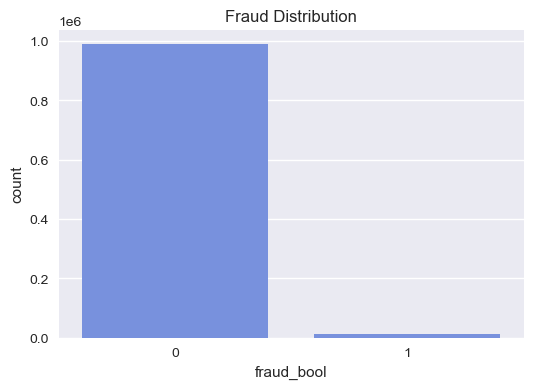


Numerical Columns:
['fraud_bool', 'income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'email_is_free', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'session_length_in_minutes', 'keep_alive_session', 'device_distinct_emails_8w', 'device_fraud_count', 'month']


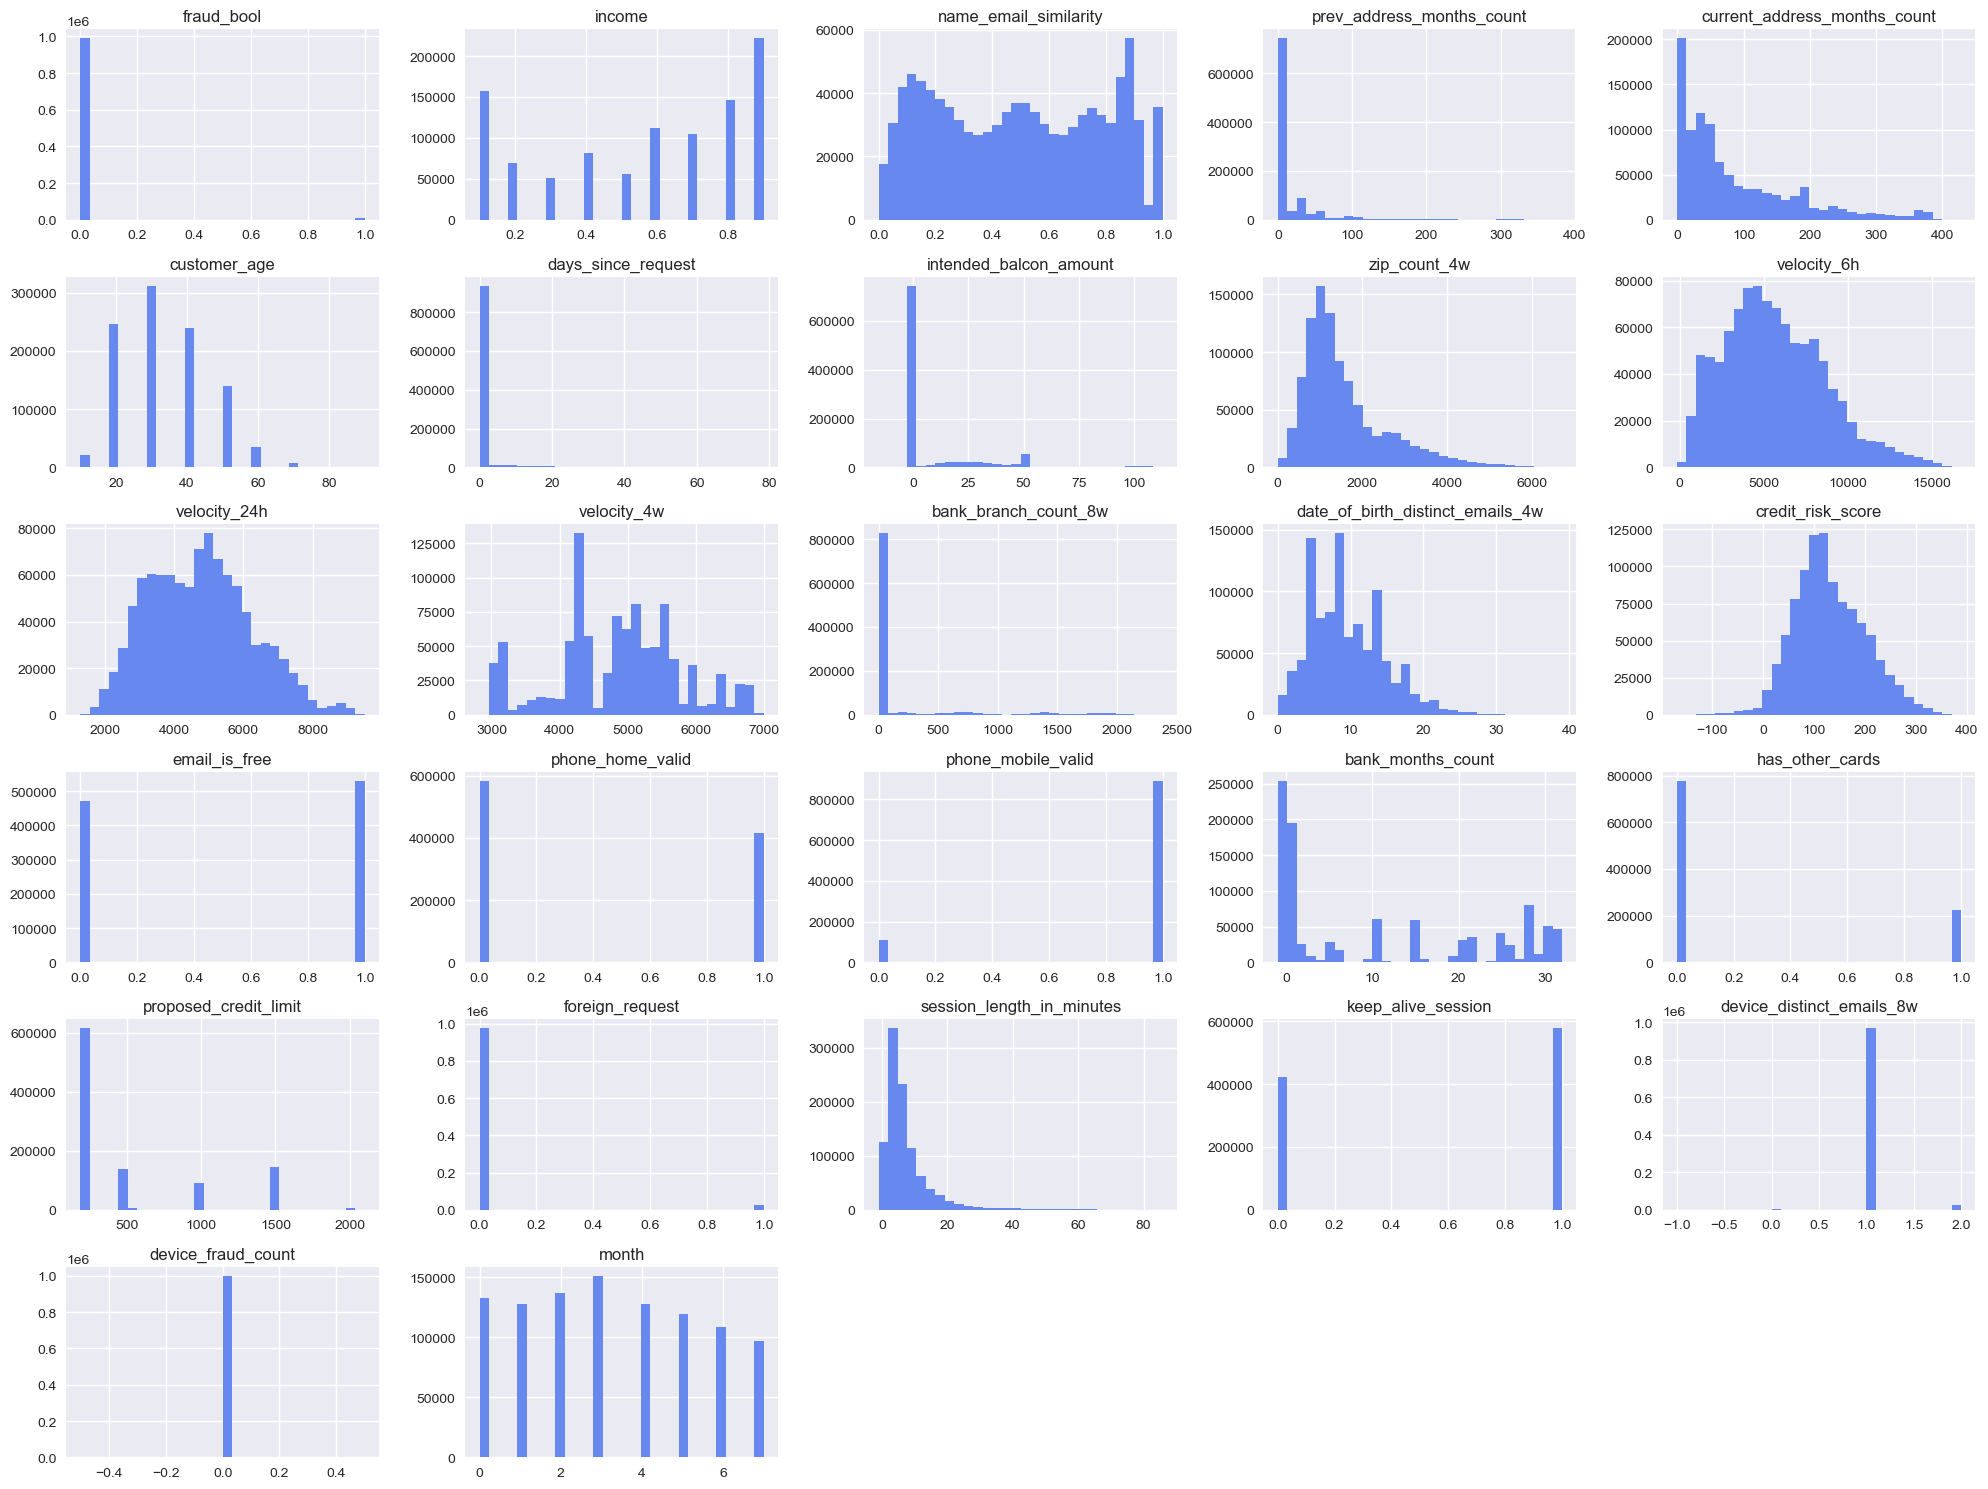

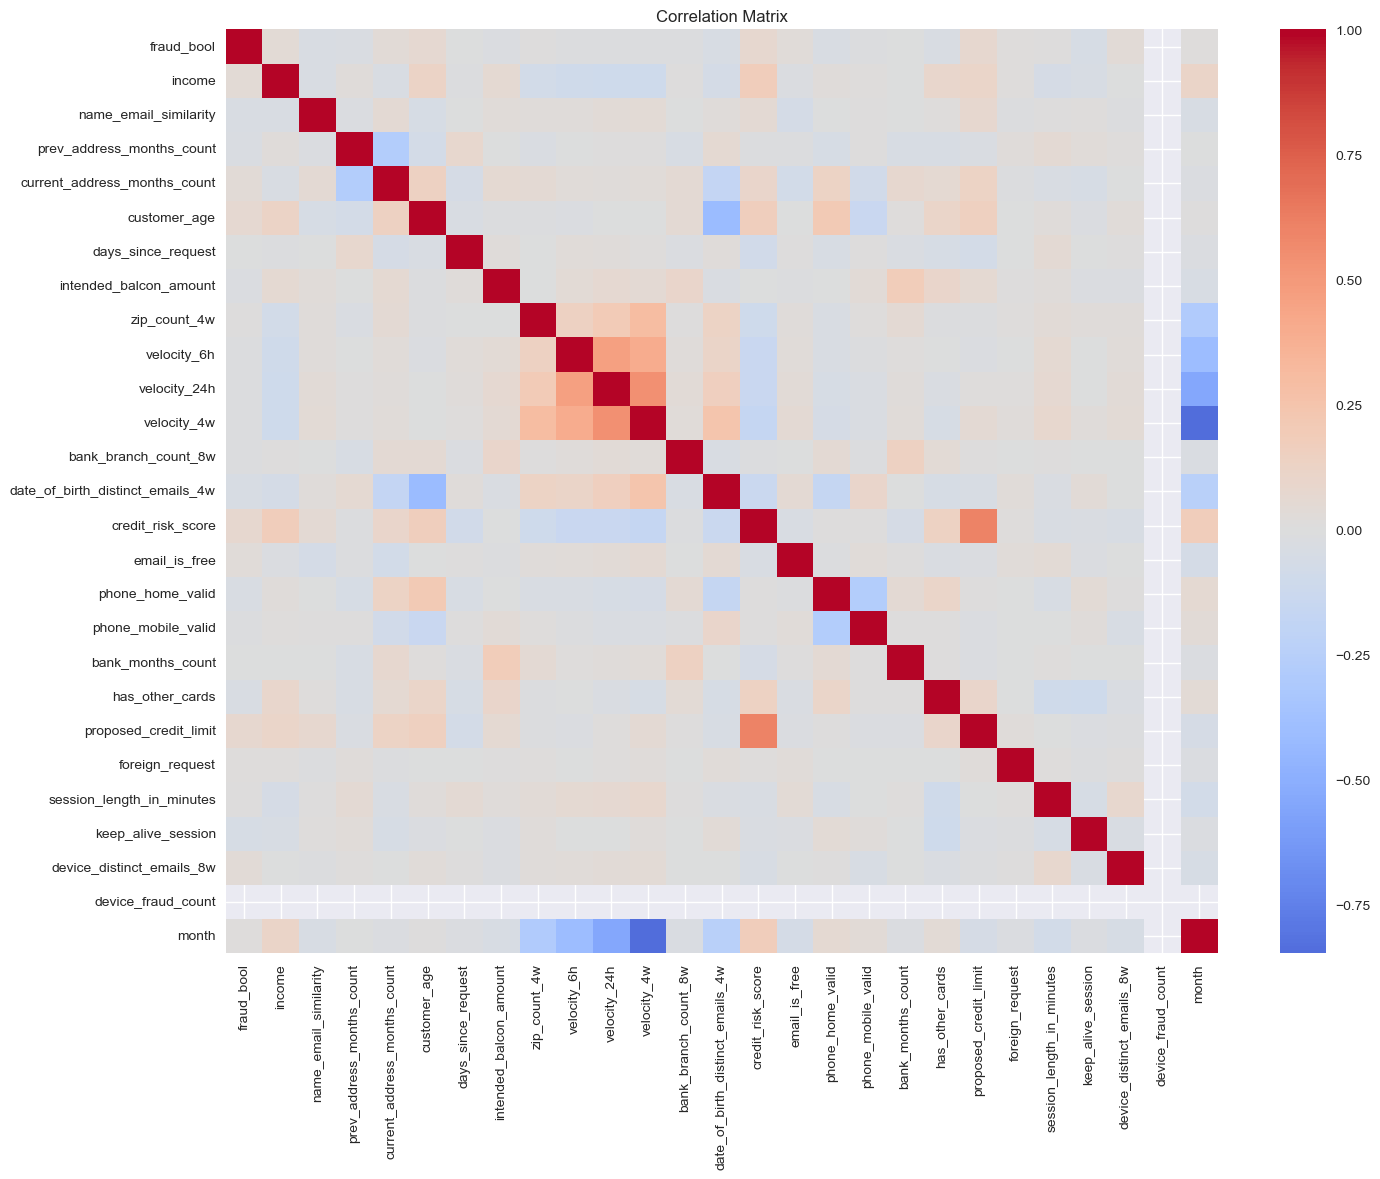

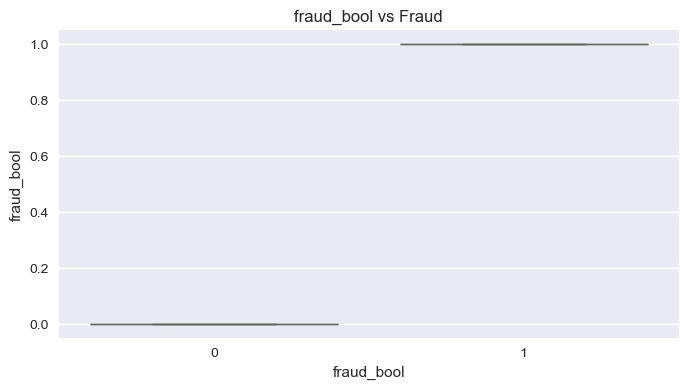

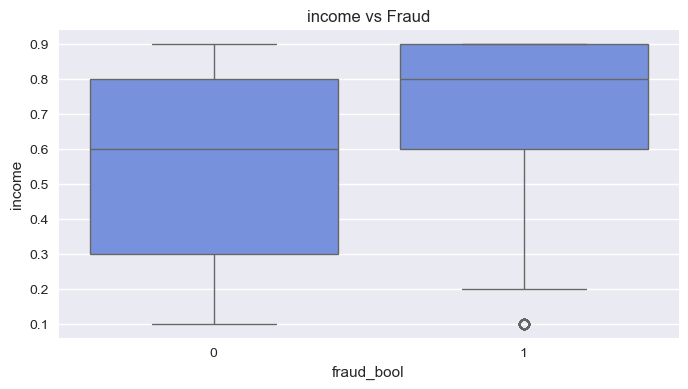

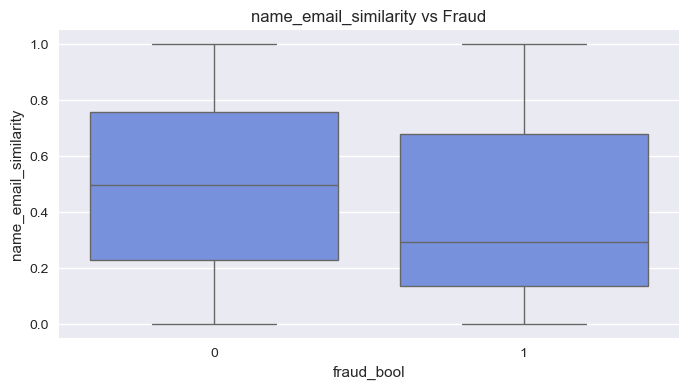

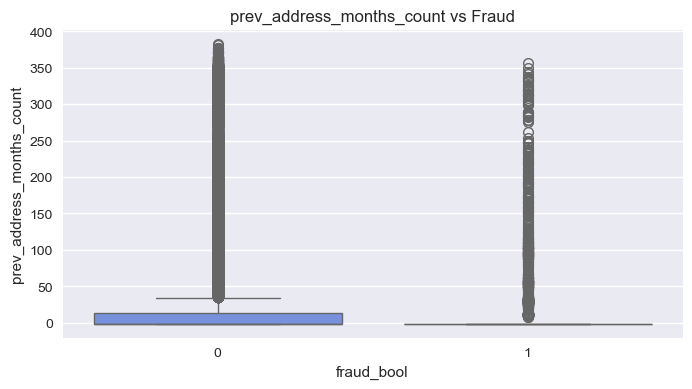

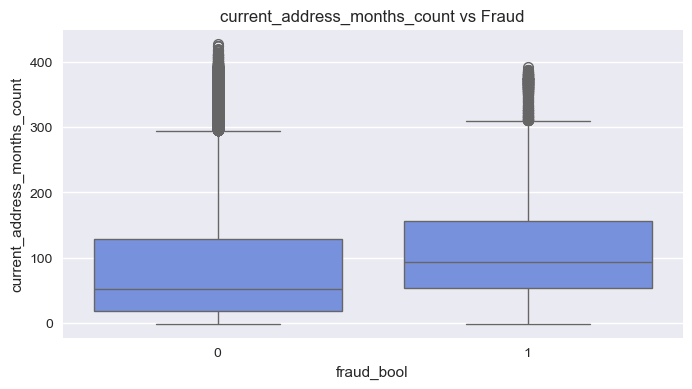

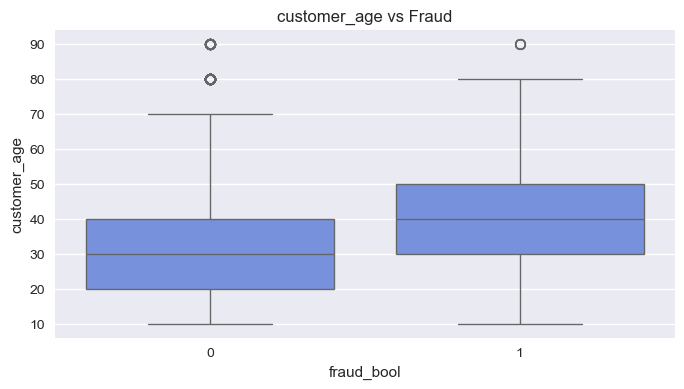

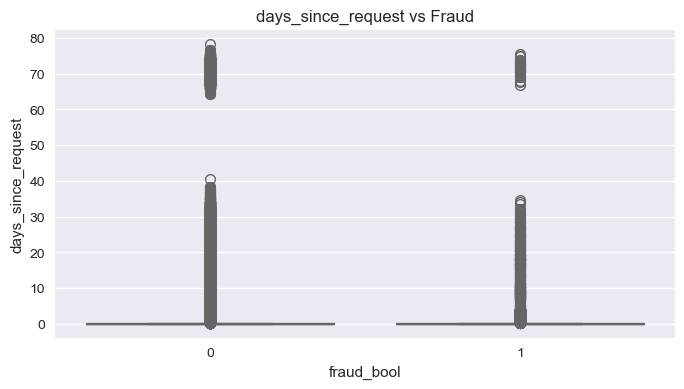

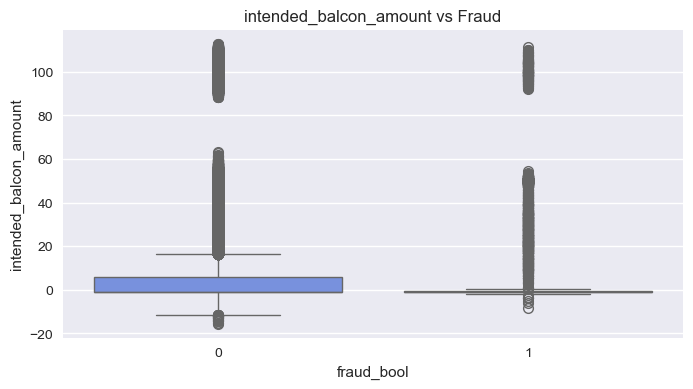

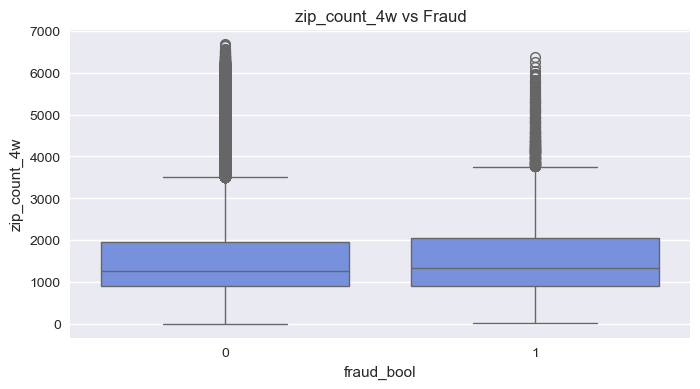

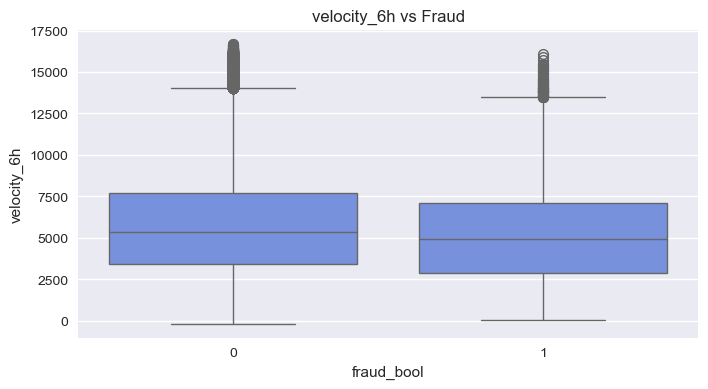

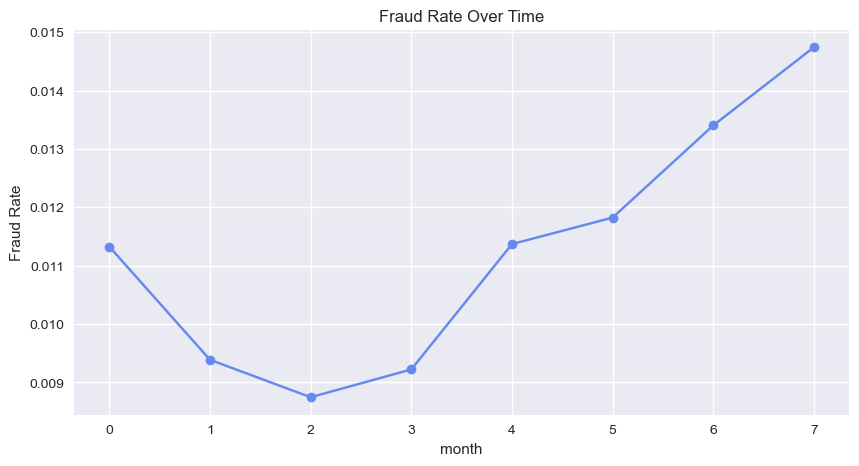


EDA COMPLETED


In [1]:
# ==========================================================
# EDA_BAF.PY
# Exploratory Data Analysis - BAF Dataset
# ==========================================================

# ==========================================================
# IMPORTS
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# CONFIG
# ==========================================================
plt.style.use("seaborn-v0_8")
sns.set_palette("coolwarm")

pd.set_option("display.max_columns", None)

# ==========================================================
# LOAD DATA
# ==========================================================
df = pd.read_csv("Base.csv")

print("===================================================")
print("BAF DATASET LOADED")
print("===================================================")

print(f"Shape: {df.shape}")

# ==========================================================
# BASIC INFO
# ==========================================================
print("\n--- INFO ---")
print(df.info())

print("\n--- DESCRIBE ---")
print(df.describe())

# ==========================================================
# TARGET DISTRIBUTION
# ==========================================================
print("\n--- TARGET DISTRIBUTION ---")

fraud_rate = df["fraud_bool"].mean()

print(f"Fraud rate: {fraud_rate:.4%}")

plt.figure(figsize=(6,4))

sns.countplot(x="fraud_bool", data=df)

plt.title("Fraud Distribution")

plt.show()

# ==========================================================
# NUMERICAL FEATURES
# ==========================================================
num_cols = df.select_dtypes(include=np.number).columns

print("\nNumerical Columns:")
print(num_cols.tolist())

# ==========================================================
# HISTOGRAMS
# ==========================================================
df[num_cols].hist(
    figsize=(20,15),
    bins=30
)

plt.tight_layout()
plt.show()

# ==========================================================
# CORRELATION MATRIX
# ==========================================================
plt.figure(figsize=(16,12))

corr = df[num_cols].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

# ==========================================================
# FRAUD VS NON FRAUD
# ==========================================================
for col in num_cols[:10]:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x="fraud_bool",
        y=col,
        data=df
    )

    plt.title(f"{col} vs Fraud")

    plt.show()

# ==========================================================
# TEMPORAL DISTRIBUTION
# ==========================================================
if "month" in df.columns:

    monthly_fraud = (
        df.groupby("month")["fraud_bool"]
        .mean()
    )

    monthly_fraud.plot(
        kind="line",
        marker="o",
        figsize=(10,5)
    )

    plt.title("Fraud Rate Over Time")

    plt.ylabel("Fraud Rate")

    plt.show()

print("\nEDA COMPLETED")